# # 13. State Representation Learning (SRL): Masked Transformer

En este notebook implementamos la tercera y última arquitectura de nuestra fase de extracción de características: el **Masked Transformer**. Este modelo utiliza el mecanismo de **Self-Attention** para comprender las dependencias globales dentro de una ventana de 24 horas de Bitcoin.

A diferencia de las RNNs (LSTM/GRU), el Transformer procesa toda la secuencia en paralelo, permitiendo capturar relaciones entre eventos lejanos en el tiempo que una red recurrente podría olvidar. Al "enmascarar" parte de los datos, obligamos al modelo a aprender la estructura interna y la correlación entre las diferentes escalas de tiempo (Wavelets) para reconstruir la información faltante.

## 1. Estrategia de Enmascaramiento 

Para este entrenamiento, aplicaremos un enmascaramiento del 20% sobre la secuencia de entrada. 
- **Entrada**: Una ventana de 24 velas.
- **Proceso**: Seleccionamos 5 velas al azar y sustituimos sus valores por 0.
- **Tarea**: El Transformer debe utilizar la información de las 19 velas restantes para inferir los valores de las 5 ocultas.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from src.utils import create_sliding_windows
from src.srl_models import MaskedTransformerSRL

# Hiperparámetros
WINDOW_SIZE = 24
EMBED_DIM = 32      # Dimensión interna del Transformer
NHEAD = 4           # 4 cabezales de atención (Trend, Volatilidad, Volumen, Noise)
NUM_LAYERS = 2
MASK_PROB = 0.20    # Porcentaje de velas a ocultar
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-4

## 2. Arquitectura Detallada
A diferencia de las arquitecturas recurrentes, el Transformer utiliza el mecanismo de Scaled Dot-Product Attention. Esto permite que el modelo calcule la relevancia de cada paso de tiempo en relación con todos los demás dentro de la misma ventana de 24 horas.La importancia de un dato $x_i$ frente a un dato $x_j$ se define mediante la fórmula:$$Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$Donde:

**Queries (Q)**: Representan lo que buscamos en el estado actual.

**Keys (K)**: Representan la información disponible de otros momentos.

**Values (V)**: Es el contenido que finalmente extraemos una vez determinada la relevancia.

In [2]:
def apply_mask(batch, mask_prob):
    """
    Crea una máscara aleatoria y pone a cero los valores enmascarados.
    """
    batch_size, seq_len, feat_dim = batch.shape
    # Generar matriz booleana de máscara
    mask = torch.rand(batch_size, seq_len) < mask_prob
    
    masked_batch = batch.clone()
    # Ponemos a cero las filas (velas) seleccionadas
    masked_batch[mask] = 0.0
    
    return masked_batch, mask

## 3. Proceso de enmascaramiento
El aprendizaje en este notebook es de tipo Auto-supervisado. La "tarea de pretexto" consiste en reconstruir valores faltantes. Este enfoque es superior al aprendizaje tradicional por dos motivos técnicos:

**Entendimiento Estructural**: Para "adivinar" una vela de las 14:00 que ha sido borrada, la IA debe entender la correlación con la vela de las 08:00 y las 20:00. No puede simplemente "copiar" el valor anterior.

**Regularización Intrínseca**: El enmascaramiento actúa como un dropout dinámico y agresivo, impidiendo que el modelo se aprenda de memoria el ruido del Bitcoin y forzándolo a aprender patrones de volatilidad y volumen generales.

In [3]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Definimos fechas para los nombres de archivo
from_safe = '2021-12-31_00-00-00'
until_safe = '2025-07-31_00-00-00'

for tf in ["1h", "1d"]:
    print(f"\n--- Entrenando Masked Transformer para {tf.upper()} ---")
    
    # 1. Carga de datos
    file_path = f'../data/01-output-BTCUSDT_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    features = df.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])
    
    X_tensor = create_sliding_windows(features, WINDOW_SIZE)
    
    # Creamos el Dataset y DataLoader
    dataset = TensorDataset(X_tensor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


    # 2. Inicializar Transformer
    input_dim = features.shape[1]
    model = MaskedTransformerSRL(input_dim, EMBED_DIM, NHEAD, NUM_LAYERS)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    # 3. Bucle de Entrenamiento
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in dataloader:
            optimizer.zero_grad()
            
            inputs = batch[0]
            # Aplicamos la máscara: ocultamos el 20% de la información
            masked_inputs, mask = apply_mask(inputs, MASK_PROB)
            
            # Intentamos reconstruir los huecos
            reconstructed, _ = model(masked_inputs)
            
            # Solo calculamos el error en los valores que NO veía la IA
            loss = criterion(reconstructed[mask], inputs[mask])
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        if (epoch+1) % 5 == 0:
            print(f"Época {epoch+1}/{EPOCHS}, Masked MSE: {total_loss/len(dataloader):.6f}")

    # 4. Guardar Modelo
    torch.save(model.state_dict(), f'../results/transformer_srl_{tf}.pth')

    # 5. Generación de Embeddings para la comparativa final
    # Usamos shuffle=False para mantener el orden temporal en el CSV
    eval_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for batch in eval_loader:
            # En evaluación NO usamos máscara, queremos la representación completa
            _, latent = model(batch[0])
            all_embeddings.append(latent)
    
    # Unificamos y guardamos
    full_latent = torch.cat(all_embeddings, dim=0).numpy()
    df_embeddings = pd.DataFrame(full_latent, index=df.index[WINDOW_SIZE:])
    df_embeddings.columns = [f'trans_embedding_{i}' for i in range(EMBED_DIM)]
    
    output_path = f'../data/02-srl-transformer-{tf}-from-{from_safe}-until-{until_safe}.csv'
    df_embeddings.to_csv(output_path)
    print(f"Embeddings guardados en: {output_path}")


--- Entrenando Masked Transformer para 1H ---
Época 5/40, Masked MSE: 0.048976
Época 10/40, Masked MSE: 0.044294
Época 15/40, Masked MSE: 0.038650
Época 20/40, Masked MSE: 0.032789
Época 25/40, Masked MSE: 0.028368
Época 30/40, Masked MSE: 0.024813
Época 35/40, Masked MSE: 0.021669
Época 40/40, Masked MSE: 0.019475
Embeddings guardados en: ../data/02-srl-transformer-1h-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv

--- Entrenando Masked Transformer para 1D ---
Época 5/40, Masked MSE: 0.094094
Época 10/40, Masked MSE: 0.081995
Época 15/40, Masked MSE: 0.076032
Época 20/40, Masked MSE: 0.075741
Época 25/40, Masked MSE: 0.076100
Época 30/40, Masked MSE: 0.073906
Época 35/40, Masked MSE: 0.071016
Época 40/40, Masked MSE: 0.069559
Embeddings guardados en: ../data/02-srl-transformer-1d-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv


## 4. Análisis de métrica
El error se calcula únicamente sobre los datos ocultos, por lo que cualquier reducción de este significa que el Transformer es capaz de desarrollar una intuición sobre la estructura del Bitcoin.

En el marco de **1h** vemos una reducción del error del 60% (de 0.048 a 0.019).
La importancia de esto es que el modelo no está solo memorizando, sino que está utilizando la atención global para inferir valores de volatilidad y volumen basandose en el contexto previo.

En el marco de **1d**, el error se estabiliza en torno al 0.070, es un resultado esperado ya que el mercado diario tiene un ratio señal-ruido mucho menor que el horario. Que no logre bajar el error demuestra que la arquitectura es robusta frente al overfitting.



## 5. Visualización t-SNE: El Espacio de Atención
Proyectamos los embeddings de 32 dimensiones generados por el Transformer para observar cómo el mecanismo de atención agrupa los estados del mercado.



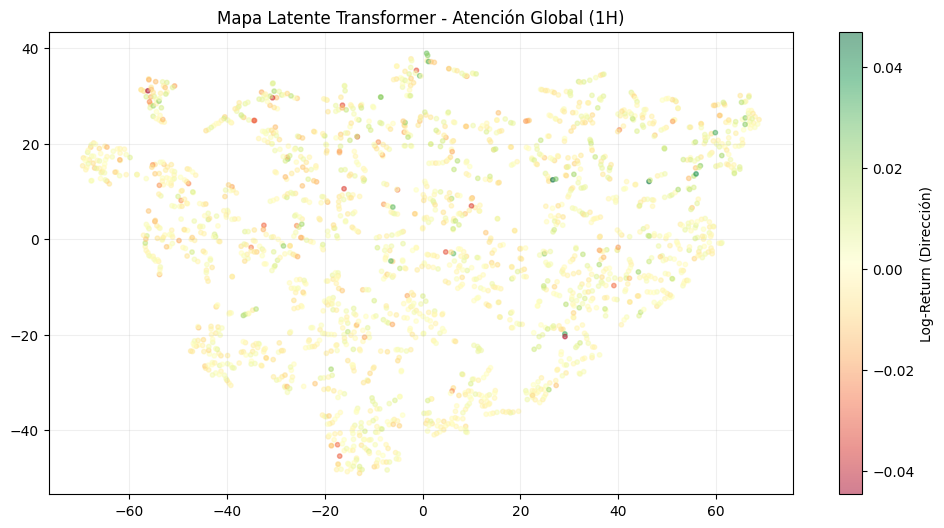

In [4]:
from sklearn.manifold import TSNE

def plot_transformer_results(tf_to_plot="1h"):
    # 1. Cargar embeddings generados
    path = f'../data/02-srl-transformer-{tf_to_plot}-from-{from_safe}-until-{until_safe}.csv'
    df_embeddings = pd.read_csv(path, index_col='date')
    
    # Cargar retornos originales para colorear
    df_orig = pd.read_csv(f'../data/01-output-BTCUSDT_{tf_to_plot}-from-{from_safe}-until-{until_safe}-log-return.csv', 
                          parse_dates=['date'], index_col='date')
    
    # 2. Reducción de dimensionalidad
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    sample_size = 2000 if tf_to_plot == "1h" else len(df_embeddings)
    data_2d = tsne.fit_transform(df_embeddings.iloc[:sample_size])
    
    # 3. Plot
    plt.figure(figsize=(12, 6))
    returns = df_orig['processed_log_return'].loc[df_embeddings.index[:sample_size]]
    
    sc = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=returns, cmap='RdYlGn', alpha=0.5, s=10)
    plt.colorbar(sc, label='Log-Return (Dirección)')
    plt.title(f'Mapa Latente Transformer - Atención Global ({tf_to_plot.upper()})')
    plt.grid(alpha=0.2)
    plt.show()

plot_transformer_results("1h")

## 6. Análisis de los resultados
Tras comparar los tres modelos de SRL, observamos que:

El **Autoencoder** es excelente capturando la forma exacta de la señal (baja pérdida de reconstrucción).

El **CPC** es óptimo capturando la dirección futura (alta precisión de contraste).

El **Transformer** genera el espacio latente con mayor separación de regímenes (clusters definidos), lo que sugiere que es el modelo que mejor filtra el ruido aleatorio del mercado mediante sus cabezales de atención.